<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/week5_day2_dalychallenges_day2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Classification Types Overview

*   **Binary Classification**: Classifying data into one of two distinct classes (e.g., Spam vs. Not Spam).
*   **Multi-class Classification**: Classifying data into one of more than two classes, where each instance belongs to exactly one class (e.g., Digit recognition 0-9).
*   **Multi-label Classification**: Classifying data where each instance can belong to multiple classes simultaneously (e.g., Tagging a photo with 'Sunset', 'Beach', and 'Nature').

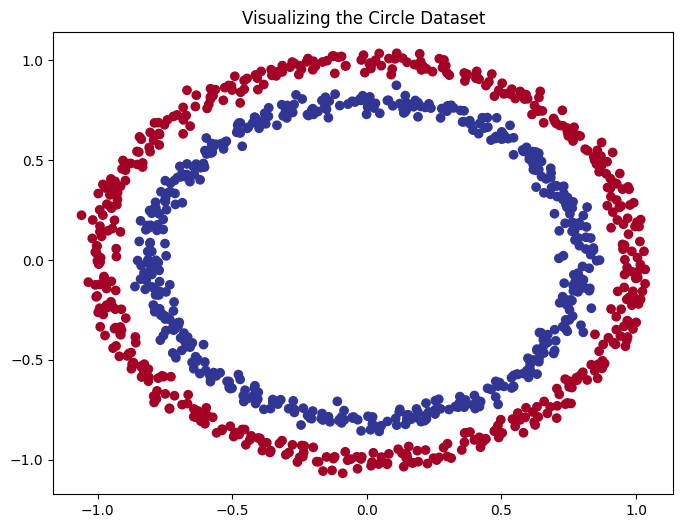

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# 2. Create the dataset
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Visualizing the Circle Dataset")
plt.show()

In [2]:
# 3. Build a Basic Neural Network
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1) # Simple model with 1 neuron
])

model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['accuracy'])

print("Training Basic Model (model_1)...")
history_1 = model_1.fit(X, y, epochs=5, verbose=0)
print(f"Final Accuracy: {history_1.history['accuracy'][-1]:.4f}")

Training Basic Model (model_1)...
Final Accuracy: 0.4960


In [5]:
# 5. Decision Boundary Function
def plot_decision_boundary(model, X, y):
    # Define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Create X values (we're going to predict on all of these)
    x_in = np.c_[xx.ravel(), yy.ravel()]

    # Make predictions
    y_pred = model.predict(x_in)

    # Check for multi-class
    if len(y_pred[0]) > 1:
        print("doing multi-class classification")
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("doing binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

Training Final Model...
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9900 - loss: 0.0231
Test Loss: 0.0231
Test Accuracy: 0.9900
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classification


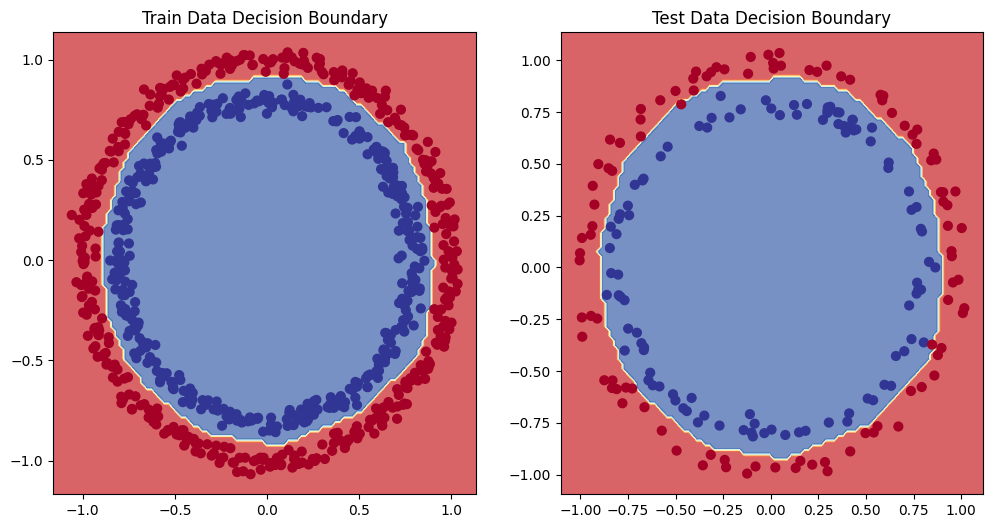

In [4]:
# 6 & 7. Improved Model with Activation Functions and Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a more complex model using non-linear activation functions
model_final = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu'), # ReLU for hidden layer
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Sigmoid for binary output
])

model_final.compile(loss='binary_crossentropy',
                    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                    metrics=['accuracy'])

print("Training Final Model...")
history_final = model_final.fit(X_train, y_train, epochs=100, verbose=0)

# 8. Evaluation
loss, accuracy = model_final.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train Data Decision Boundary")
plot_decision_boundary(model_final, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test Data Decision Boundary")
plot_decision_boundary(model_final, X_test, y_test)
plt.show()